In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_seven.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.SIGMOID)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/week


/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 102.11629811581842
R2 -> -0.08261743819840728
MAPE -> 0.14279549444689849


{'d2_absolute_error_score': -0.015865992143527796,
 'd2_pinball_score': -0.015865992143527796,
 'd2_tweedie_score': -0.08261743819840728,
 'explained_variance_score': 0.01092673421588286,
 'max_error': 421.4008591877714,
 'mean_absolute_error': 70.88459544435848,
 'mean_absolute_percentage_error': 0.14279549444689849,
 'mean_gamma_deviance': 0.03291857231639982,
 'mean_poisson_deviance': 18.264254877319107,
 'mean_squared_error': 10427.738340878701,
 'mean_squared_log_error': 0.038464454451171026,
 'median_absolute_error': 45.82485365713188,
 'r2_score': -0.08261743819840728,
 'root_mean_squared_error': 102.11629811581842,
 'root_mean_squared_log_error': 0.19612356934129827}

Plots:

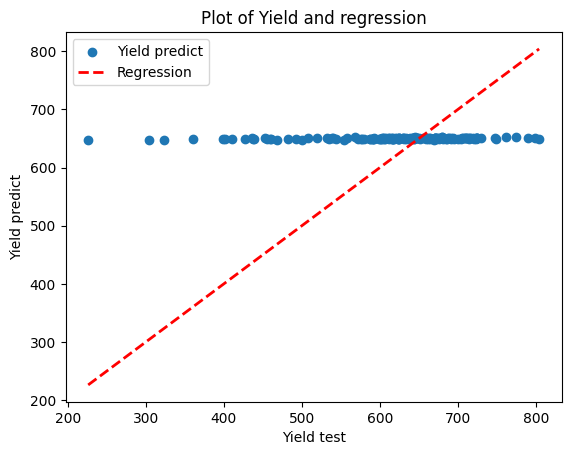

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 647.5126591877714,
  'error': 1.8636836254798352},
 {'truth': 304.5419,
  'predict': 646.5555771325751,
  'error': 1.1230430923711157},
 {'truth': 322.9881,
  'predict': 648.1643725980983,
  'error': 1.0067747777645628},
 {'truth': 360.0, 'predict': 648.4887147562766, 'error': 0.8013575409896573},
 {'truth': 398.2896,
  'predict': 649.7994917159358,
  'error': 0.6314749160307871},
 {'truth': 400.8056,
  'predict': 649.0725962350562,
  'error': 0.6194199787504369},
 {'truth': 409.865, 'predict': 649.195333575676, 'error': 0.5839247888345578},
 {'truth': 427.0, 'predict': 649.7864508947946, 'error': 0.5217481285592379},
 {'truth': 436.0, 'predict': 650.2957057053751, 'error': 0.49150391216829153},
 {'truth': 437.0, 'predict': 648.9240100363536, 'error': 0.48495196804657575},
 {'truth': 438.9351,
  'predict': 648.8986167924968,
  'error': 0.4783475206072534},
 {'truth': 453.0, 'predict': 650.3957160920276, 'error': 0.43575213265348245},
 {'truth': 455.805